# Titanic Data Visualization Dashboard

## Objective

The objective of this project is to build a mini data visualization dashboard using the Titanic dataset.

The project focuses on:
- Data cleaning
- Feature engineering
- Exploratory data analysis
- Data storytelling through visualizations

The goal is to communicate meaningful insights about passenger survival using multiple chart types and concise interpretations.

In [8]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


# Dataset Overview

The Titanic dataset contains information about passengers aboard the Titanic, including demographic details, ticket information, and survival status.

Important variables include:
- Age
- Sex
- Passenger Class
- Fare
- Embarkation Port
- Survival Status

This dataset is commonly used for learning data analysis, visualization, and predictive modeling.

In [9]:
df = pd.read_csv("../data/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Data Cleaning

Before analysis, the dataset must be cleaned to improve data quality.

Cleaning steps performed:
- Missing Age values filled using median age
- Cabin column removed due to excessive missing values
- Duplicate records removed

These steps ensure more reliable analysis and visualization.

In [10]:
# Fill missing age values
df["Age"] = df["Age"].fillna(df["Age"].median())

# Remove Cabin column
df.drop(columns=["Cabin"], inplace=True)

# Remove duplicate rows
df = df.drop_duplicates()

# Feature Engineering

New features are created to improve analysis.

Features Created:
- FamilySize = SibSp + Parch
- AgeGroup based on passenger age ranges

These features help reveal patterns that are difficult to observe from raw data alone.

In [11]:
# Family size feature
df["FamilySize"] = df["SibSp"] + df["Parch"]

# Age groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,19,35,60,100],
    labels=["Child","Teen","Young Adult","Adult","Senior"]
)

# Visualization 1: Passenger Age Distribution

This histogram shows the age distribution of Titanic passengers.

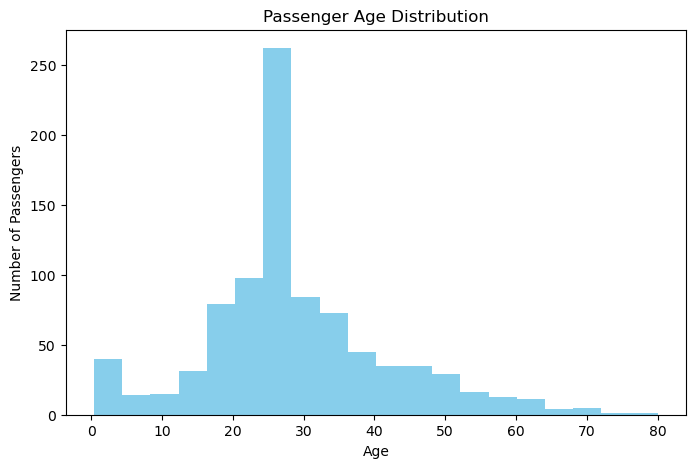

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20, color="skyblue")

plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

### Insight

Most passengers were young adults between 20 and 40 years old. Very few passengers were elderly.

# Visualization 2: Survival Rate by Gender

This chart compares survival rates between male and female passengers.

C:\Users\rudra\AppData\Local\Temp\ipykernel_22316\1681806305.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


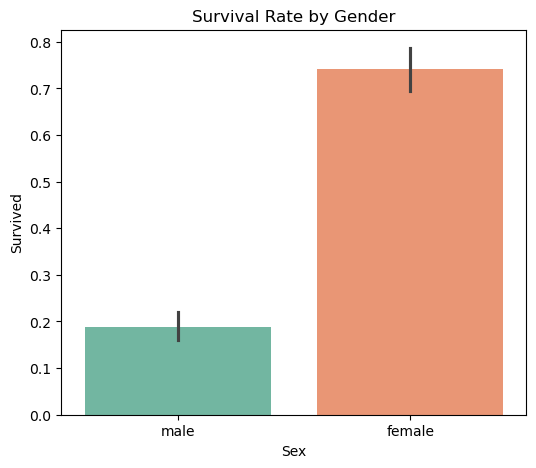

In [13]:
plt.figure(figsize=(6,5))

sns.barplot(
    x="Sex",
    y="Survived",
    data=df,
    palette="Set2"
)

plt.title("Survival Rate by Gender")

plt.show()

### Insight

Female passengers had significantly higher survival rates compared to male passengers, reflecting evacuation priorities during the disaster.

# Visualization 3: Fare Distribution by Passenger Class

This boxplot shows how ticket fares vary across passenger classes.

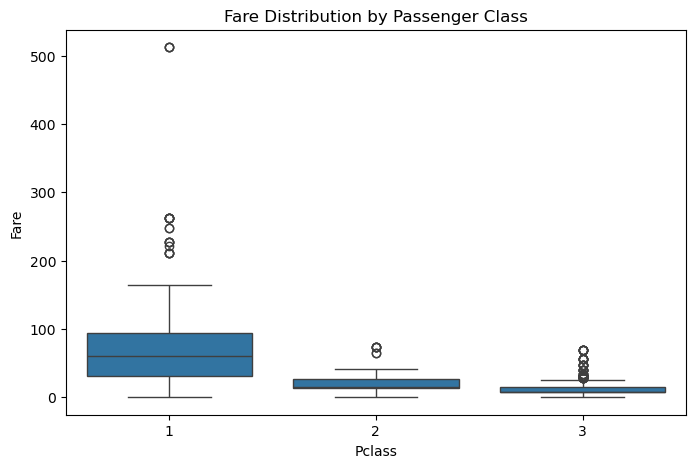

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Pclass",
    y="Fare",
    data=df
)

plt.title("Fare Distribution by Passenger Class")

plt.show()

### Insight

First-class passengers generally paid higher fares and showed greater variability in ticket prices compared to other classes.

# Visualization 4: Age vs Fare

This scatterplot explores the relationship between passenger age and fare, colored by survival status.

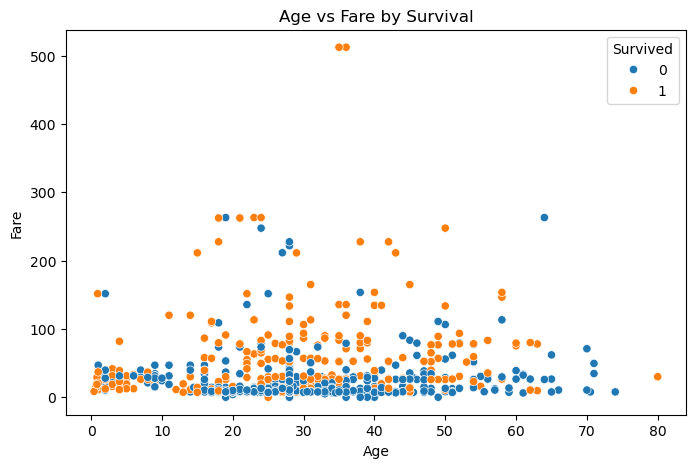

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Age",
    y="Fare",
    hue="Survived",
    data=df
)

plt.title("Age vs Fare by Survival")

plt.show()

### Insight

Higher fare passengers appear more concentrated among survivors, suggesting that passenger class may have influenced survival opportunities.

# Visualization 5: Correlation Heatmap

This heatmap displays relationships between numerical variables in the dataset.

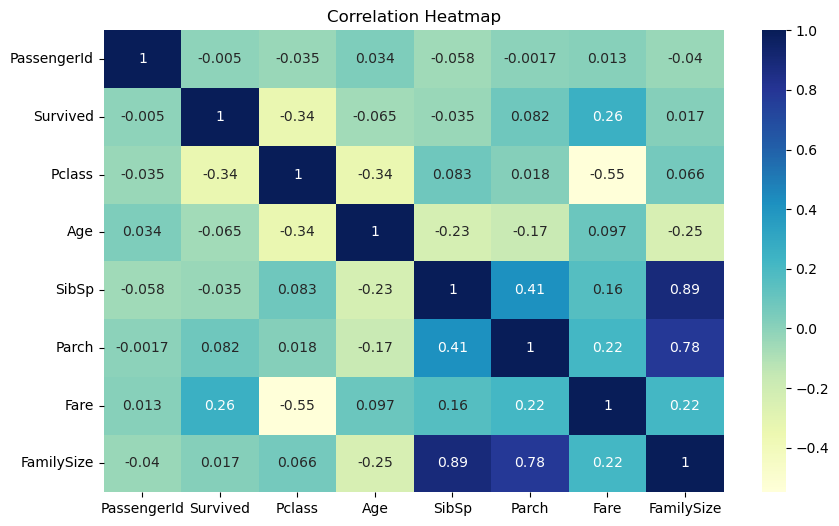

In [16]:
numeric_df = df.select_dtypes(
    include=["int64","float64"]
)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Correlation Heatmap")

plt.show()

### Insight

Passenger class and fare show noticeable relationships with survival, indicating that socioeconomic factors played a role during the disaster.

# Visualization 6: Survival Rate by Passenger Class

This chart compares survival rates across different passenger classes.

C:\Users\rudra\AppData\Local\Temp\ipykernel_22316\3752991204.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


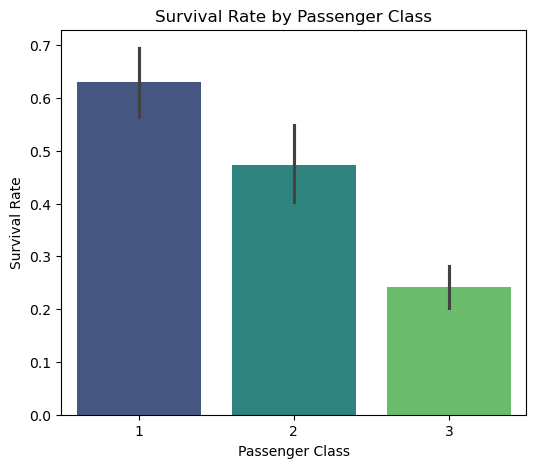

In [17]:
plt.figure(figsize=(6,5))

sns.barplot(
    x="Pclass",
    y="Survived",
    data=df,
    palette="viridis"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

### Insight

First-class passengers had significantly higher survival rates than third-class passengers.

# Visualization 7:  Survival by Embarkation Port

C:\Users\rudra\AppData\Local\Temp\ipykernel_22316\2306089921.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


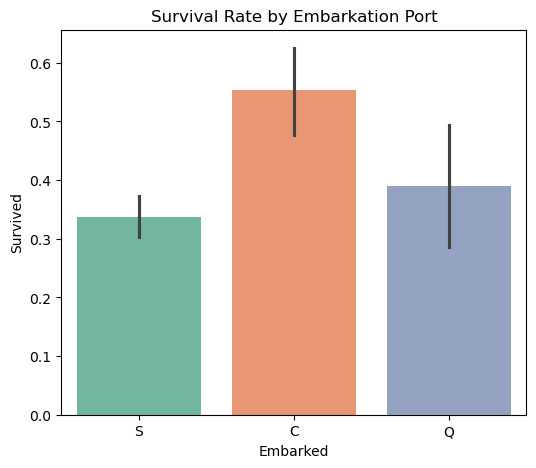

In [18]:
plt.figure(figsize=(6,5))

sns.barplot(
    x="Embarked",
    y="Survived",
    data=df,
    palette="Set2"
)

plt.title("Survival Rate by Embarkation Port")

plt.show()

### Insight

Survival rates varied among embarkation ports, suggesting differences in passenger demographics and ticket classes.

# Visualization 8: Family Size Distribution

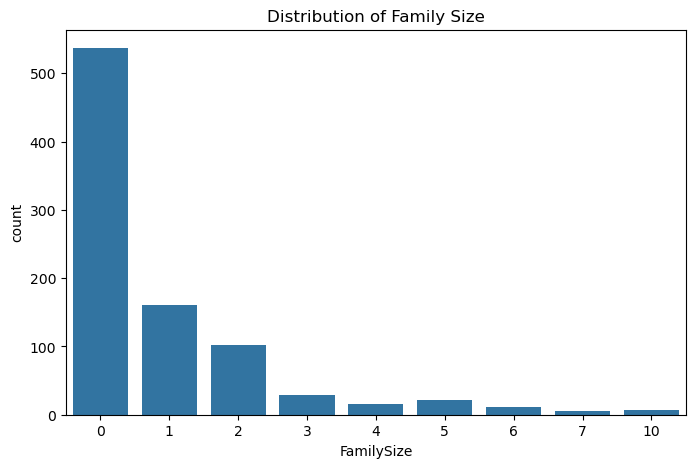

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="FamilySize",
    data=df
)

plt.title("Distribution of Family Size")

plt.show()

### Insight

Most passengers traveled alone or with a very small family group.

# Key Findings

## Major Insights from the Analysis

1. Female passengers had significantly higher survival rates than male passengers.

2. First-class passengers showed the highest survival rates, indicating that passenger class played an important role in survival outcomes.

3. Most passengers aboard the Titanic were young adults between 20 and 40 years of age.

4. Children generally had better survival chances compared to older age groups.

5. Passengers who paid higher fares tended to have better survival outcomes, suggesting a relationship between socioeconomic status and survival.

6. Survival rates varied across embarkation ports, indicating differences in passenger demographics and travel characteristics.

7. Most passengers traveled alone or with a small family group, while large family groups were relatively uncommon.

8. Family size appeared to influence survival, with passengers traveling in small family groups often showing better survival rates than those traveling alone or in very large groups.

9. Correlation analysis showed that passenger class, fare, and survival were related, helping identify important factors associated with survival outcomes.

10. Data visualization made it easier to identify patterns and communicate insights effectively from the dataset.